# Horse and human classification 

In [1]:
# # Download the dataset
# !mkdir -p data
# !wget https://storage.googleapis.com/tensorflow-1-public/course2/week3/horse-or-human.zip 
# !unzip horse-or-human.zip -d data/train
# !wget https://storage.googleapis.com/tensorflow-1-public/course2/week3/validation-horse-or-human.zip
# !unzip validation-horse-or-human.zip -d data/test

In [2]:
# !rm -rf horse-or-human.zip validation-horse-or-human.zip

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os

In [4]:
device = "MPS" if tf.config.list_physical_devices('GPU') else 'CPU'
print(f"Using device: {device}")

Using device: MPS


In [5]:
# Fix paths
train_dir = 'data/train'
test_dir = 'data/test'

Training set: 1027 images (500 horses, 527 humans)


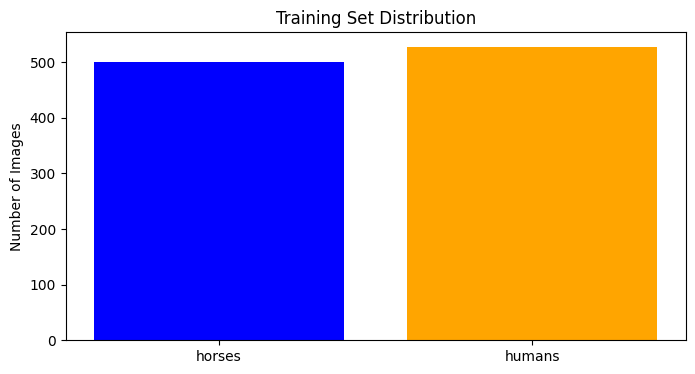

In [6]:
#Class distribution
classes = ['horses', 'humans']
horse_count = len(tf.io.gfile.glob(train_dir + '/horses/*'))
human_count = len(tf.io.gfile.glob(train_dir + '/humans/*'))
train_counts = horse_count + human_count
print(f'Training set: {train_counts} images ({horse_count} horses, {human_count} humans)')

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(classes, [horse_count, human_count], color=['blue', 'orange'])
ax.set_title('Training Set Distribution')
ax.set_ylabel('Number of Images')
plt.show()

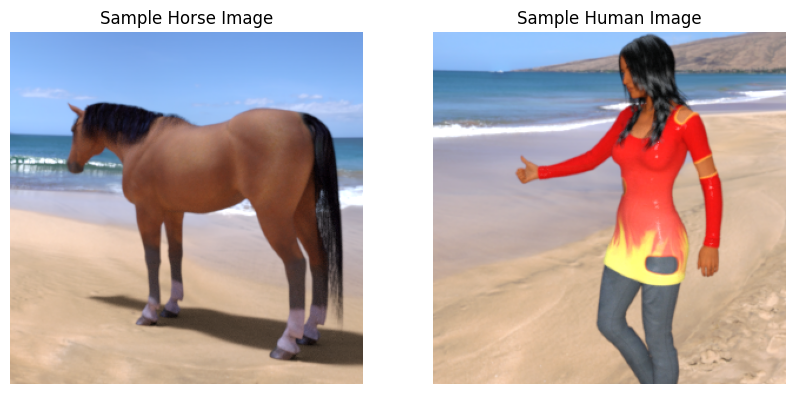

In [7]:
import random

# Pick random sample from each class
horse_files = os.listdir('data/train/horses')
human_files = os.listdir('data/train/humans')

sample_horse = random.choice(horse_files)
sample_human = random.choice(human_files)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(plt.imread(f'data/train/horses/{sample_horse}'))
ax[0].set_title('Sample Horse Image')
ax[0].axis('off')

ax[1].imshow(plt.imread(f'data/train/humans/{sample_human}'))
ax[1].set_title('Sample Human Image')
ax[1].axis('off')
plt.show()

In [8]:
# Simple data generator (without rescale — just aug for inspection)
transforms = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=(0.8, 1.2),
    shear_range=10,
    zoom_range=0.1,
    fill_mode='nearest',
    horizontal_flip=True,
)

train_generator = transforms.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

Found 1027 images belonging to 2 classes.


In [9]:
# Transfer Learning with MobileNetV2
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

INPUT_SHAPE = (224, 224, 3)

base_model = MobileNetV2(
    input_shape=INPUT_SHAPE,
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)
model.summary()

2026-06-04 14:23:03.829869: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-06-04 14:23:03.829894: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-06-04 14:23:03.829903: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-06-04 14:23:03.829920: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-04 14:23:03.829932: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 1027 images belonging to 2 classes.
Found 256 images belonging to 2 classes.


In [12]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

history = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=30,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30


2026-06-04 14:23:05.566112: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


33/33 ━━━━━━━━━━━━━━━━━━━━ 9s 208ms/step - accuracy: 0.6543 - loss: 0.6165 - val_accuracy: 0.7734 - val_loss: 0.5225 - learning_rate: 1.0000e-04
Epoch 2/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 166ms/step - accuracy: 0.7760 - loss: 0.4932 - val_accuracy: 0.9141 - val_loss: 0.3966 - learning_rate: 1.0000e-04
Epoch 3/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 163ms/step - accuracy: 0.8520 - loss: 0.3862 - val_accuracy: 0.9609 - val_loss: 0.3149 - learning_rate: 1.0000e-04
Epoch 4/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 154ms/step - accuracy: 0.8997 - loss: 0.3066 - val_accuracy: 0.9648 - val_loss: 0.2544 - learning_rate: 1.0000e-04
Epoch 5/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 155ms/step - accuracy: 0.9299 - loss: 0.2484 - val_accuracy: 0.9688 - val_loss: 0.2094 - learning_rate: 1.0000e-04
Epoch 6/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 160ms/step - accuracy: 0.9552 - loss: 0.2094 - val_accuracy: 0.9766 - val_loss: 0.1746 - learning_rate: 1.0000e-04
Epoch 7/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 155ms/step - accuracy: 0.9542 - lo

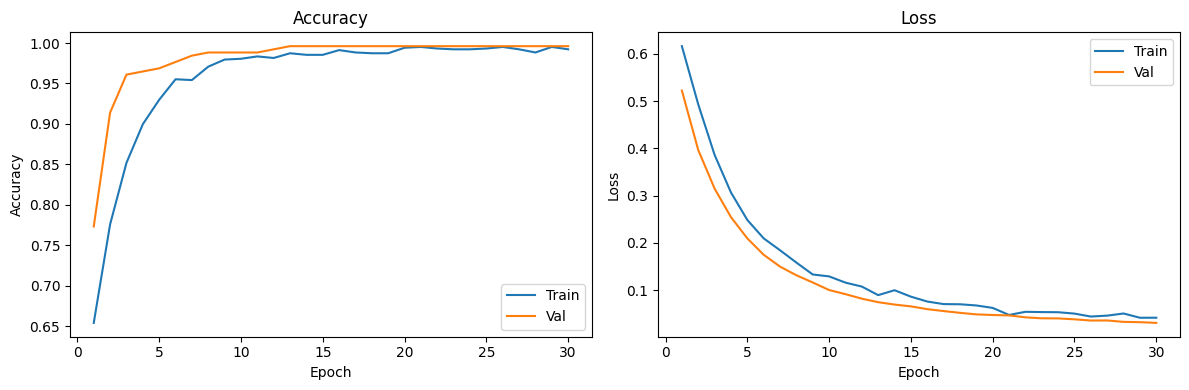

In [13]:
# Plot training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, acc, label='Train')
ax1.plot(epochs, val_acc, label='Val')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(epochs, loss, label='Train')
ax2.plot(epochs, val_loss, label='Val')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()